# Loan Default Risk Modeling

This notebook runs the full experiment pipeline: preprocessing, EDA, baseline logistic regression, kNN tuning, polynomial expansion, regularization, and final model comparison.


In [1]:
import os
import sys
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
COEFFICIENTS_DIR = RESULTS_DIR / "coefficients"

for directory in [RESULTS_DIR, FIGURES_DIR, TABLES_DIR, COEFFICIENTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(RESULTS_DIR / ".matplotlib"))

import matplotlib

RUNNING_IN_NOTEBOOK = "ipykernel" in sys.modules
if not RUNNING_IN_NOTEBOOK:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", message="Inconsistent values: penalty=.*")
sns.set_theme(style="whitegrid")


def show_or_close(figure_obj):
    if RUNNING_IN_NOTEBOOK:
        plt.show()
    else:
        plt.close(figure_obj)

processed_files = [
    PROJECT_DIR / "X_train_processed.csv",
    PROJECT_DIR / "X_val_processed.csv",
    PROJECT_DIR / "X_test_processed.csv",
    PROJECT_DIR / "y_train_processed.csv",
    PROJECT_DIR / "y_val_processed.csv",
    PROJECT_DIR / "y_test_processed.csv",
]

if all(path.exists() for path in processed_files):
    print("Processed CSV files already exist. Skipping pipeline.py regeneration.")
else:
    print("Processed CSV files missing. Running pipeline.py to regenerate them.")
    subprocess.run([sys.executable, "pipeline.py"], check=True)


Starting data preprocessing pipeline...
Initial shape: (1000, 5)
Data split - Train: 700, Validation: 150, Test: 150
Feature scaling applied successfully without data leakage.
Processed CSV files saved to: /Users/alex/Desktop/phys 515/515 project

Sample of Scaled and Encoded X_train:
       income  loan_amount  employment_status_Unemployed
973 -0.074348     0.722092                             0
413  0.498297    -0.614081                             0
566  0.240676     0.684966                             1


CompletedProcess(args=['/usr/local/bin/python3.13', 'pipeline.py'], returncode=0)

## EDA and Preprocessing Evidence

In [2]:
raw_df = pd.read_csv("loan_default_prediction.csv")

raw_df.info()
print(raw_df.head())
print(raw_df.describe(include="all"))

missing_values = raw_df.isnull().sum().rename("missing_count")
class_distribution = raw_df["default"].value_counts().rename("count").to_frame()
class_distribution["proportion"] = raw_df["default"].value_counts(normalize=True)
employment_default_rate = raw_df.groupby("employment_status")["default"].agg(["count", "mean"])
correlation_matrix = raw_df.select_dtypes(include=[np.number]).corr()

missing_values.to_csv(TABLES_DIR / "missing_values.csv")
class_distribution.to_csv(TABLES_DIR / "class_distribution.csv")
employment_default_rate.to_csv(TABLES_DIR / "employment_default_rate.csv")
correlation_matrix.to_csv(TABLES_DIR / "numeric_correlation_matrix.csv")

print(missing_values)
print(class_distribution)
print(employment_default_rate)
print(correlation_matrix)

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   loan_id            1000 non-null   str  
 1   income             1000 non-null   int64
 2   loan_amount        1000 non-null   int64
 3   employment_status  1000 non-null   str  
 4   default            1000 non-null   int64
dtypes: int64(3), str(2)
memory usage: 39.2 KB
  loan_id  income  loan_amount employment_status  default
0   L1000    9270        22969          Employed        1
1   L1001    2860        46659          Employed        0
2   L1002    7390        38545        Unemployed        1
3   L1003    7191        37668          Employed        0
4   L1004   13964        24061          Employed        0
       loan_id        income   loan_amount employment_status      default
count     1000   1000.000000   1000.000000              1000  1000.000000
unique    1000           NaN           Na

In [3]:
def detect_outliers_iqr(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return {
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "num_outliers": len(outliers),
    }

outlier_summary = pd.DataFrame([
    detect_outliers_iqr(raw_df, "income"),
    detect_outliers_iqr(raw_df, "loan_amount"),
])
outlier_summary.to_csv(TABLES_DIR / "outlier_summary.csv", index=False)
print(outlier_summary)

       feature  lower_bound  upper_bound  num_outliers
0       income    -3826.750    21047.250             0
1  loan_amount   -24316.625    74390.375             0


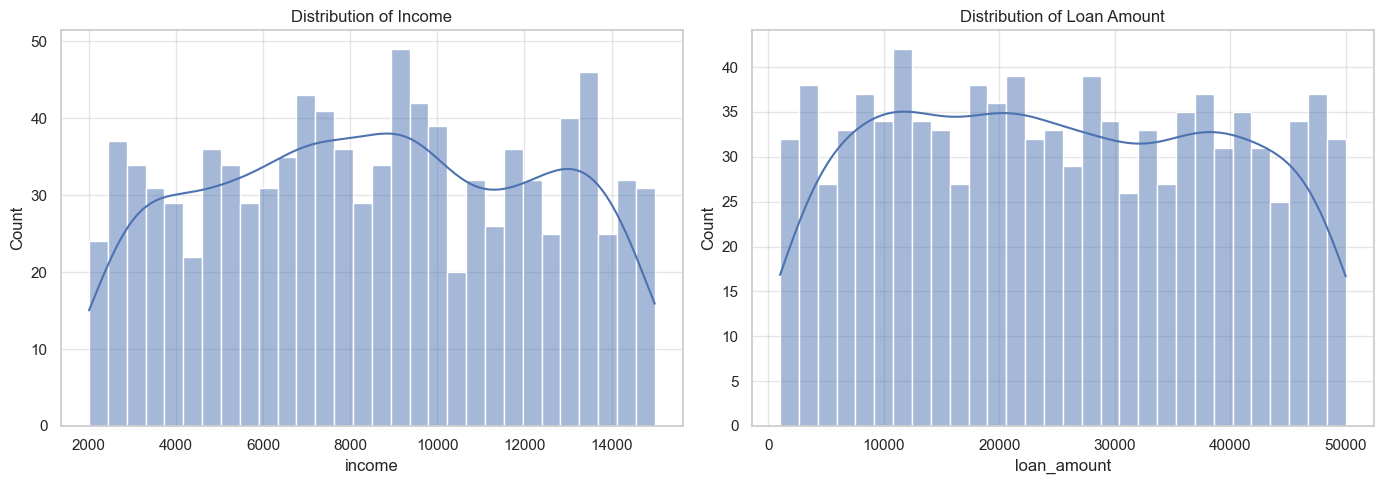

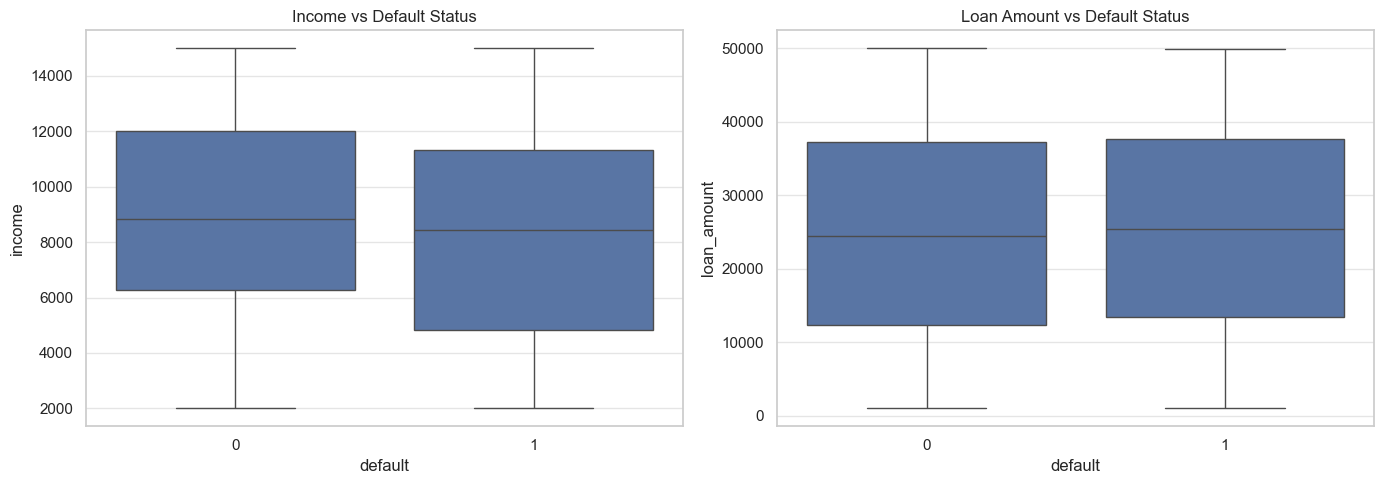

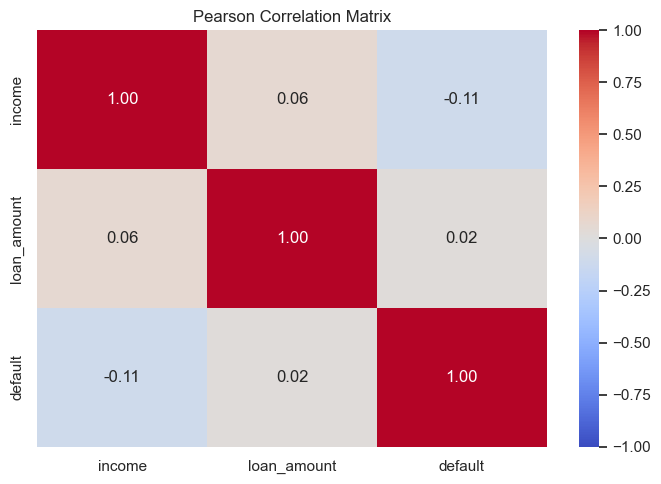

In [4]:
dist_fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(raw_df["income"], kde=True, bins=30, ax=axes[0])
axes[0].set_title("Distribution of Income")
sns.histplot(raw_df["loan_amount"], kde=True, bins=30, ax=axes[1])
axes[1].set_title("Distribution of Loan Amount")
dist_fig.tight_layout()
dist_fig.savefig(FIGURES_DIR / "eda_feature_distributions.png", dpi=200)
show_or_close(dist_fig)

box_fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="default", y="income", data=raw_df, ax=axes[0])
axes[0].set_title("Income vs Default Status")
sns.boxplot(x="default", y="loan_amount", data=raw_df, ax=axes[1])
axes[1].set_title("Loan Amount vs Default Status")
box_fig.tight_layout()
box_fig.savefig(FIGURES_DIR / "eda_default_relationships.png", dpi=200)
show_or_close(box_fig)

corr_fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="coolwarm", ax=ax)
ax.set_title("Pearson Correlation Matrix")
corr_fig.tight_layout()
corr_fig.savefig(FIGURES_DIR / "eda_correlation_heatmap.png", dpi=200)
show_or_close(corr_fig)


## Load Processed Splits

The processed CSV files are generated by `pipeline.py`. They use a 70/15/15 stratified split, one-hot encoding for `employment_status`, and training-set-only standardization for `income` and `loan_amount`.

In [5]:
X_train = pd.read_csv("X_train_processed.csv")
X_val = pd.read_csv("X_val_processed.csv")
X_test = pd.read_csv("X_test_processed.csv")
y_train = pd.read_csv("y_train_processed.csv")["default"]
y_val = pd.read_csv("y_val_processed.csv")["default"]
y_test = pd.read_csv("y_test_processed.csv")["default"]

split_shapes = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "X_shape": [X_train.shape, X_val.shape, X_test.shape],
    "y_shape": [y_train.shape, y_val.shape, y_test.shape],
})
split_shapes.to_csv(TABLES_DIR / "split_shapes.csv", index=False)
print(split_shapes)
print(X_train.head())

        split   X_shape y_shape
0       train  (700, 3)  (700,)
1  validation  (150, 3)  (150,)
2        test  (150, 3)  (150,)
     income  loan_amount  employment_status_Unemployed
0 -0.074348     0.722092                             0
1  0.498297    -0.614081                             0
2  0.240676     0.684966                             1
3 -1.623957    -0.181349                             1
4  0.467515    -1.210153                             1


In [6]:
def make_unscaled_splits(df, random_state=RANDOM_STATE):
    df_model = df.drop(columns=["loan_id"])
    df_model = pd.get_dummies(df_model, columns=["employment_status"], drop_first=True, dtype=int)
    features = df_model.drop(columns=["default"])
    target = df_model["default"]
    x_train_raw, x_temp_raw, y_train_raw, y_temp_raw = train_test_split(
        features, target, test_size=0.30, random_state=random_state, stratify=target
    )
    x_val_raw, x_test_raw, y_val_raw, y_test_raw = train_test_split(
        x_temp_raw, y_temp_raw, test_size=0.50, random_state=random_state, stratify=y_temp_raw
    )
    return x_train_raw, x_val_raw, x_test_raw, y_train_raw, y_val_raw, y_test_raw

X_train_unscaled, X_val_unscaled, X_test_unscaled, y_train_unscaled, y_val_unscaled, y_test_unscaled = make_unscaled_splits(raw_df)

## Shared Evaluation Utilities

In [7]:
def safe_name(name):
    return (
        name.lower()
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("(", "")
        .replace(")", "")
        .replace("=", "")
    )

confusion_matrices = {}


def evaluate_model(model_name, estimator, x_train_data, y_train_data, x_val_data, y_val_data, x_test_data, y_test_data):
    predictions = {
        "train": estimator.predict(x_train_data),
        "validation": estimator.predict(x_val_data),
        "test": estimator.predict(x_test_data),
    }

    result = {
        "Model": model_name,
        "Train Accuracy": accuracy_score(y_train_data, predictions["train"]),
        "Train F1": f1_score(y_train_data, predictions["train"]),
        "Validation Accuracy": accuracy_score(y_val_data, predictions["validation"]),
        "Validation F1": f1_score(y_val_data, predictions["validation"]),
        "Test Accuracy": accuracy_score(y_test_data, predictions["test"]),
        "Test Precision": precision_score(y_test_data, predictions["test"]),
        "Test Recall": recall_score(y_test_data, predictions["test"]),
        "Test F1": f1_score(y_test_data, predictions["test"]),
    }

    cm = pd.DataFrame(
        confusion_matrix(y_test_data, predictions["test"]),
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"],
    )
    confusion_matrices[model_name] = cm
    cm.to_csv(TABLES_DIR / f"confusion_matrix_{safe_name(model_name)}.csv")

    print(f"========== {model_name} ==========")
    print("Test Confusion Matrix:")
    print(cm)
    print("\nTest Classification Report:")
    print(classification_report(y_test_data, predictions["test"]))

    return result

## Problem 1: Logistic Regression Baseline

In [8]:
log_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_model.fit(X_train, y_train)

log_results = evaluate_model(
    "Logistic Regression",
    log_model,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
)
log_results

========== Logistic Regression ==========
Test Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           57           20
Actual 1           16           57

Test Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.74      0.76        77
           1       0.74      0.78      0.76        73

    accuracy                           0.76       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.76      0.76      0.76       150



{'Model': 'Logistic Regression',
 'Train Accuracy': 0.72,
 'Train F1': 0.7191977077363897,
 'Validation Accuracy': 0.7,
 'Validation F1': 0.7058823529411765,
 'Test Accuracy': 0.76,
 'Test Precision': 0.7402597402597403,
 'Test Recall': 0.7808219178082192,
 'Test F1': 0.76}

In [9]:
logistic_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0],
})
logistic_coefficients["Abs_Coefficient"] = logistic_coefficients["Coefficient"].abs()
logistic_coefficients["Odds_Ratio"] = np.exp(logistic_coefficients["Coefficient"])
logistic_coefficients = logistic_coefficients.sort_values("Abs_Coefficient", ascending=False)
logistic_coefficients.to_csv(COEFFICIENTS_DIR / "logistic_regression_coefficients.csv", index=False)
print(logistic_coefficients)

employment_effect = logistic_coefficients[logistic_coefficients["Feature"] == "employment_status_Unemployed"].iloc[0]
print("Log-odds change for Unemployed vs Employed:", employment_effect["Coefficient"])
print("Odds multiplier for Unemployed vs Employed:", employment_effect["Odds_Ratio"])

                        Feature  Coefficient  Abs_Coefficient  Odds_Ratio
2  employment_status_Unemployed     1.906656         1.906656    6.730542
0                        income    -0.310582         0.310582    0.733020
1                   loan_amount     0.111825         0.111825    1.118317
Log-odds change for Unemployed vs Employed: 1.9066557390748875
Odds multiplier for Unemployed vs Employed: 6.730542429023183


## Problem 2: kNN Tuning, Scaling Sensitivity, and Model Comparison

In [10]:
k_values = list(range(1, 52, 2))
knn_tuning_results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    val_pred = knn.predict(X_val)
    knn_tuning_results.append({
        "k": k,
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Validation Precision": precision_score(y_val, val_pred),
        "Validation Recall": recall_score(y_val, val_pred),
        "Validation F1": f1_score(y_val, val_pred),
    })

knn_tuning_df = pd.DataFrame(knn_tuning_results)
knn_tuning_df.to_csv(TABLES_DIR / "knn_tuning_results.csv", index=False)
print(knn_tuning_df)

best_k = int(knn_tuning_df.sort_values(["Validation F1", "Validation Accuracy"], ascending=False).iloc[0]["k"])
print("Best k based on validation F1:", best_k)

     k  Train Accuracy  Train F1  Validation Accuracy  Validation Precision  \
0    1        1.000000  1.000000             0.620000              0.617647   
1    3        0.820000  0.818966             0.680000              0.681159   
2    5        0.798571  0.798859             0.680000              0.671233   
3    7        0.771429  0.773371             0.666667              0.649351   
4    9        0.747143  0.756534             0.673333              0.639535   
5   11        0.754286  0.763736             0.686667              0.651163   
6   13        0.755714  0.767978             0.680000              0.650602   
7   15        0.755714  0.768606             0.680000              0.650602   
8   17        0.751429  0.762943             0.680000              0.650602   
9   19        0.751429  0.763587             0.693333              0.658824   
10  21        0.748571  0.761518             0.693333              0.658824   
11  23        0.748571  0.762162             0.69333

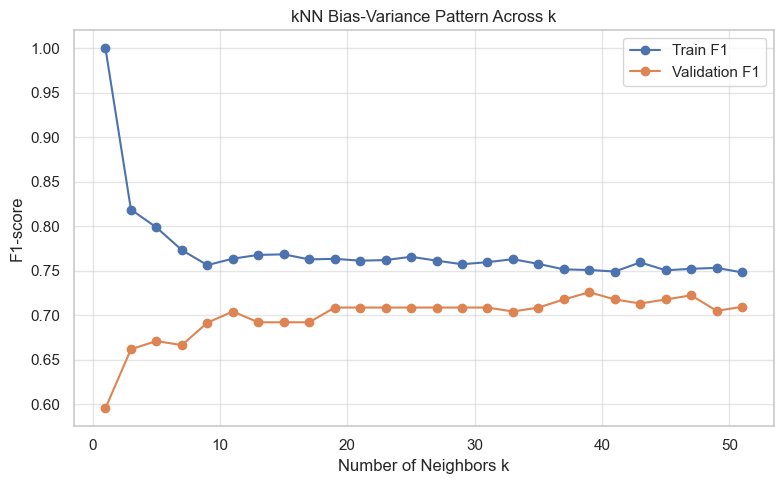

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(knn_tuning_df["k"], knn_tuning_df["Train F1"], marker="o", label="Train F1")
ax.plot(knn_tuning_df["k"], knn_tuning_df["Validation F1"], marker="o", label="Validation F1")
ax.set_xlabel("Number of Neighbors k")
ax.set_ylabel("F1-score")
ax.set_title("kNN Bias-Variance Pattern Across k")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "knn_train_validation_f1_by_k.png", dpi=200)
show_or_close(fig)

In [12]:
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train, y_train)

knn_results = evaluate_model(
    f"kNN (k={best_k})",
    best_knn,
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
)
knn_results

========== kNN (k=39) ==========
Test Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           57           20
Actual 1           13           60

Test Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.74      0.78        77
           1       0.75      0.82      0.78        73

    accuracy                           0.78       150
   macro avg       0.78      0.78      0.78       150
weighted avg       0.78      0.78      0.78       150



{'Model': 'kNN (k=39)',
 'Train Accuracy': 0.7414285714285714,
 'Train F1': 0.7510316368638239,
 'Validation Accuracy': 0.7133333333333334,
 'Validation F1': 0.7261146496815286,
 'Test Accuracy': 0.78,
 'Test Precision': 0.75,
 'Test Recall': 0.821917808219178,
 'Test F1': 0.7843137254901961}

In [13]:
knn_unscaled = KNeighborsClassifier(n_neighbors=best_k)
knn_unscaled.fit(X_train_unscaled, y_train_unscaled)

unscaled_pred = knn_unscaled.predict(X_test_unscaled)
scaled_pred = best_knn.predict(X_test)

knn_scaling_comparison = pd.DataFrame([
    {
        "Input Data": "Unscaled",
        "Test Accuracy": accuracy_score(y_test_unscaled, unscaled_pred),
        "Test Precision": precision_score(y_test_unscaled, unscaled_pred),
        "Test Recall": recall_score(y_test_unscaled, unscaled_pred),
        "Test F1": f1_score(y_test_unscaled, unscaled_pred),
    },
    {
        "Input Data": "Scaled",
        "Test Accuracy": accuracy_score(y_test, scaled_pred),
        "Test Precision": precision_score(y_test, scaled_pred),
        "Test Recall": recall_score(y_test, scaled_pred),
        "Test F1": f1_score(y_test, scaled_pred),
    },
])
knn_scaling_comparison.to_csv(TABLES_DIR / "knn_scaling_comparison.csv", index=False)
print(knn_scaling_comparison)

  Input Data  Test Accuracy  Test Precision  Test Recall   Test F1
0   Unscaled           0.56        0.563636     0.424658  0.484375
1     Scaled           0.78        0.750000     0.821918  0.784314


## Problem 3: Polynomial Expansion and Regularized Logistic Regression

In [14]:
poly_cols = ["income", "loan_amount"]
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly_part = pd.DataFrame(
    poly.fit_transform(X_train[poly_cols]),
    columns=poly.get_feature_names_out(poly_cols),
    index=X_train.index,
)
X_val_poly_part = pd.DataFrame(
    poly.transform(X_val[poly_cols]),
    columns=poly.get_feature_names_out(poly_cols),
    index=X_val.index,
)
X_test_poly_part = pd.DataFrame(
    poly.transform(X_test[poly_cols]),
    columns=poly.get_feature_names_out(poly_cols),
    index=X_test.index,
)

other_cols = [col for col in X_train.columns if col not in poly_cols]
X_train_poly = pd.concat([X_train[other_cols], X_train_poly_part], axis=1)
X_val_poly = pd.concat([X_val[other_cols], X_val_poly_part], axis=1)
X_test_poly = pd.concat([X_test[other_cols], X_test_poly_part], axis=1)

poly_feature_summary = pd.DataFrame({
    "Original Feature Count": [X_train.shape[1]],
    "Polynomial Feature Count": [X_train_poly.shape[1]],
    "Polynomial Features": [", ".join(X_train_poly.columns)],
})
poly_feature_summary.to_csv(TABLES_DIR / "polynomial_feature_summary.csv", index=False)
print(poly_feature_summary)
print(X_train_poly.head())

   Original Feature Count  Polynomial Feature Count  \
0                       3                         6   

                                 Polynomial Features  
0  employment_status_Unemployed, income, loan_amo...  
   employment_status_Unemployed    income  loan_amount  income^2  \
0                             0 -0.074348     0.722092  0.005528   
1                             0  0.498297    -0.614081  0.248300   
2                             1  0.240676     0.684966  0.057925   
3                             1 -1.623957    -0.181349  2.637237   
4                             1  0.467515    -1.210153  0.218571   

   income loan_amount  loan_amount^2  
0           -0.053686       0.521417  
1           -0.305995       0.377096  
2            0.164855       0.469179  
3            0.294504       0.032888  
4           -0.565765       1.464470  


In [15]:
l2_model = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
l2_model.fit(X_train_poly, y_train)
l2_results = evaluate_model(
    "Polynomial + L2 Logistic Regression",
    l2_model,
    X_train_poly,
    y_train,
    X_val_poly,
    y_val,
    X_test_poly,
    y_test,
)

l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
l1_model.fit(X_train_poly, y_train)
l1_results = evaluate_model(
    "Polynomial + L1 Logistic Regression",
    l1_model,
    X_train_poly,
    y_train,
    X_val_poly,
    y_val,
    X_test_poly,
    y_test,
)

========== Polynomial + L2 Logistic Regression ==========
Test Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           57           20
Actual 1           14           59

Test Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        77
           1       0.75      0.81      0.78        73

    accuracy                           0.77       150
   macro avg       0.77      0.77      0.77       150
weighted avg       0.78      0.77      0.77       150

========== Polynomial + L1 Logistic Regression ==========
Test Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           57           20
Actual 1           14           59

Test Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.74      0.77        77
           1       0.75      0.81      0.78        73

    accuracy                           0.77       150
   macro avg       0.77  

In [16]:
coef_compare = pd.DataFrame({
    "Feature": X_train_poly.columns,
    "L2_Coefficient_C1": l2_model.coef_[0],
    "L1_Coefficient_C1": l1_model.coef_[0],
})
coef_compare["L2_Abs_C1"] = coef_compare["L2_Coefficient_C1"].abs()
coef_compare["L1_Abs_C1"] = coef_compare["L1_Coefficient_C1"].abs()
coef_compare = coef_compare.sort_values("L1_Abs_C1", ascending=False)
coef_compare.to_csv(COEFFICIENTS_DIR / "l1_l2_coefficients_C1.csv", index=False)
print(coef_compare)

                        Feature  L2_Coefficient_C1  L1_Coefficient_C1  \
0  employment_status_Unemployed           1.953856           1.984417   
1                        income          -0.301548          -0.298913   
3                      income^2           0.276084           0.274620   
4            income loan_amount          -0.140070          -0.135283   
2                   loan_amount           0.081984           0.076680   
5                 loan_amount^2           0.022888           0.016286   

   L2_Abs_C1  L1_Abs_C1  
0   1.953856   1.984417  
1   0.301548   0.298913  
3   0.276084   0.274620  
4   0.140070   0.135283  
2   0.081984   0.076680  
5   0.022888   0.016286  


In [17]:
zero_threshold = 1e-6
C_values = [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30, 100]
regularization_results = []
regularization_coefficients = []

for C in C_values:
    for penalty in ["l2", "l1"]:
        candidate_model = LogisticRegression(
            penalty=penalty,
            solver="liblinear",
            C=C,
            max_iter=1000,
            random_state=RANDOM_STATE,
        )
        candidate_model.fit(X_train_poly, y_train)
        val_pred = candidate_model.predict(X_val_poly)
        coefficients = candidate_model.coef_[0]
        zero_features = X_train_poly.columns[np.abs(coefficients) < zero_threshold].tolist()

        regularization_results.append({
            "Penalty": penalty.upper(),
            "C": C,
            "Validation Accuracy": accuracy_score(y_val, val_pred),
            "Validation F1": f1_score(y_val, val_pred),
            "Num Zero Coefs": len(zero_features),
            "Zero Features": ", ".join(zero_features),
        })

        for feature, coef in zip(X_train_poly.columns, coefficients):
            regularization_coefficients.append({
                "Penalty": penalty.upper(),
                "C": C,
                "Feature": feature,
                "Coefficient": coef,
                "Abs_Coefficient": abs(coef),
                "Is_Zero": abs(coef) < zero_threshold,
            })

regularization_df = pd.DataFrame(regularization_results)
regularization_coef_df = pd.DataFrame(regularization_coefficients)
regularization_df.to_csv(TABLES_DIR / "regularization_tuning_results.csv", index=False)
regularization_coef_df.to_csv(COEFFICIENTS_DIR / "regularization_coefficients_by_C.csv", index=False)

print(regularization_df)

   Penalty       C  Validation Accuracy  Validation F1  Num Zero Coefs  \
0       L2    0.01             0.686667       0.708075               0   
1       L1    0.01             0.513333       0.000000               6   
2       L2    0.03             0.693333       0.708861               0   
3       L1    0.03             0.700000       0.705882               4   
4       L2    0.10             0.693333       0.705128               0   
5       L1    0.10             0.700000       0.705882               1   
6       L2    0.30             0.693333       0.705128               0   
7       L1    0.30             0.693333       0.705128               1   
8       L2    1.00             0.693333       0.705128               0   
9       L1    1.00             0.693333       0.705128               0   
10      L2    3.00             0.693333       0.705128               0   
11      L1    3.00             0.693333       0.705128               0   
12      L2   10.00             0.69333

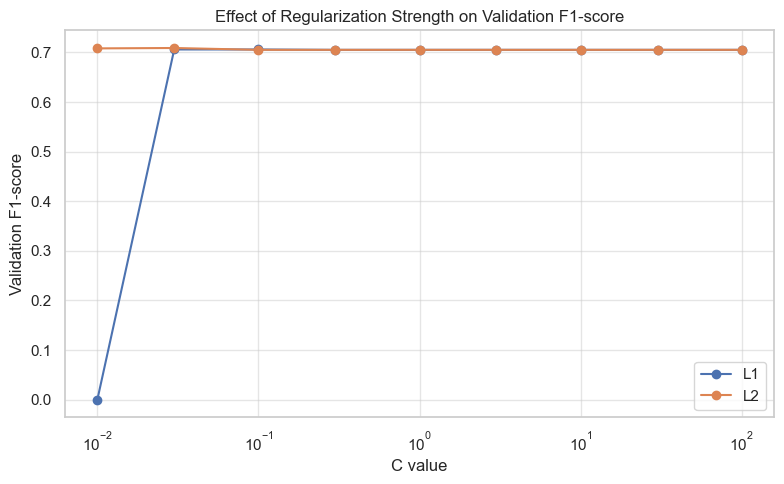

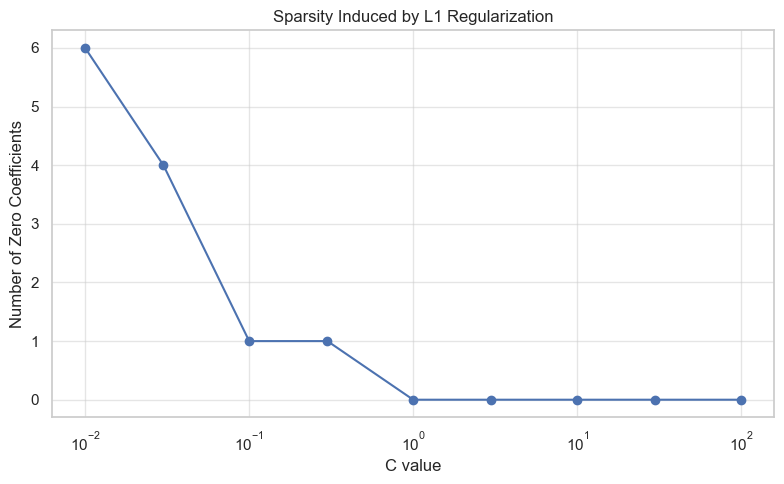

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
for penalty in ["L1", "L2"]:
    sub_df = regularization_df[regularization_df["Penalty"] == penalty]
    ax.plot(sub_df["C"], sub_df["Validation F1"], marker="o", label=penalty)
ax.set_xscale("log")
ax.set_xlabel("C value")
ax.set_ylabel("Validation F1-score")
ax.set_title("Effect of Regularization Strength on Validation F1-score")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "regularization_validation_f1_by_C.png", dpi=200)
show_or_close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
l1_sparse_df = regularization_df[regularization_df["Penalty"] == "L1"]
ax.plot(l1_sparse_df["C"], l1_sparse_df["Num Zero Coefs"], marker="o")
ax.set_xscale("log")
ax.set_xlabel("C value")
ax.set_ylabel("Number of Zero Coefficients")
ax.set_title("Sparsity Induced by L1 Regularization")
ax.grid(True)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "l1_sparsity_by_C.png", dpi=200)
show_or_close(fig)

In [19]:
best_reg = regularization_df.sort_values(["Validation F1", "Validation Accuracy"], ascending=False).iloc[0]
best_penalty = best_reg["Penalty"].lower()
best_C = float(best_reg["C"])

best_reg_model = LogisticRegression(
    penalty=best_penalty,
    solver="liblinear",
    C=best_C,
    max_iter=1000,
    random_state=RANDOM_STATE,
)
best_reg_model.fit(X_train_poly, y_train)
best_reg_results = evaluate_model(
    f"Best Polynomial Logistic ({best_reg['Penalty']}, C={best_C:g})",
    best_reg_model,
    X_train_poly,
    y_train,
    X_val_poly,
    y_val,
    X_test_poly,
    y_test,
)

best_reg_coef = pd.DataFrame({
    "Feature": X_train_poly.columns,
    "Coefficient": best_reg_model.coef_[0],
})
best_reg_coef["Abs_Coefficient"] = best_reg_coef["Coefficient"].abs()
best_reg_coef["Is_Zero"] = best_reg_coef["Abs_Coefficient"] < zero_threshold
best_reg_coef.to_csv(COEFFICIENTS_DIR / "best_regularized_polynomial_coefficients.csv", index=False)

print(best_reg)
print(best_reg_coef.sort_values("Abs_Coefficient", ascending=False))

========== Best Polynomial Logistic (L2, C=0.03) ==========
Test Confusion Matrix:
          Predicted 0  Predicted 1
Actual 0           57           20
Actual 1           11           62

Test Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.79        77
           1       0.76      0.85      0.80        73

    accuracy                           0.79       150
   macro avg       0.80      0.79      0.79       150
weighted avg       0.80      0.79      0.79       150

Penalty                      L2
C                          0.03
Validation Accuracy    0.693333
Validation F1          0.708861
Num Zero Coefs                0
Zero Features                  
Name: 2, dtype: object
                        Feature  Coefficient  Abs_Coefficient  Is_Zero
0  employment_status_Unemployed     0.931574         0.931574    False
1                        income    -0.210371         0.210371    False
3                      incom

## Final Model Comparison

                                   Model  Train Accuracy  Train F1  \
4  Best Polynomial Logistic (L2, C=0.03)        0.750000  0.761255   
1                             kNN (k=39)        0.741429  0.751032   
2    Polynomial + L2 Logistic Regression        0.728571  0.733894   
3    Polynomial + L1 Logistic Regression        0.727143  0.732118   
0                    Logistic Regression        0.720000  0.719198   

   Validation Accuracy  Validation F1  Test Accuracy  Test Precision  \
4             0.693333       0.708861       0.793333        0.756098   
1             0.713333       0.726115       0.780000        0.750000   
2             0.693333       0.705128       0.773333        0.746835   
3             0.693333       0.705128       0.773333        0.746835   
0             0.700000       0.705882       0.760000        0.740260   

   Test Recall   Test F1  
4     0.849315  0.800000  
1     0.821918  0.784314  
2     0.808219  0.776316  
3     0.808219  0.776316  
0     0.780

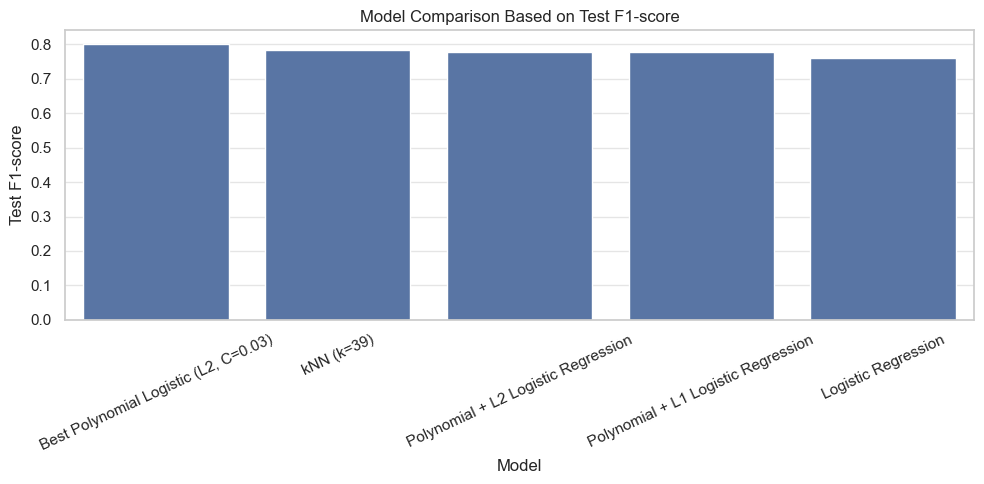

In [20]:
all_results = pd.DataFrame([
    log_results,
    knn_results,
    l2_results,
    l1_results,
    best_reg_results,
])
all_results = all_results.sort_values("Test F1", ascending=False)
all_results.to_csv(TABLES_DIR / "model_comparison.csv", index=False)
print(all_results)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=all_results, x="Model", y="Test F1", ax=ax)
ax.set_ylabel("Test F1-score")
ax.set_title("Model Comparison Based on Test F1-score")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison_test_f1.png", dpi=200)
show_or_close(fig)